# 西班牙语-英语机器翻译实验

## 毕业设计实验代码

### 实验概述
本实验基于西班牙语-英语平行语料（spa.txt），实现序列到序列（Seq2Seq）的机器翻译任务，
对比基于RNN的Seq2Seq+Attention模型与基于Transformer的翻译模型。

### 与文本分类任务的区别
| 对比维度 | 文本分类 | 机器翻译 |
|----------|----------|----------|
| 任务类型 | 序列→标签 | 序列→序列 |
| 模型结构 | 仅Encoder | Encoder + Decoder |
| 输出 | 固定类别数 | 可变长度序列 |
| 解码方式 | 无 | 自回归逐词生成 |
| 评价指标 | Accuracy/F1 | BLEU分数 |

### 实验模型
| 序号 | 模型 | 核心机制 |
|------|------|----------|
| 1 | Seq2Seq + Attention (GRU) | RNN编码器-解码器 + Bahdanau注意力 |
| 2 | Transformer | 自注意力 + 交叉注意力 |

### 数据集
- spa.txt: 英语-西班牙语平行语料
- 约118,964对翻译句对
- 格式: 英语\t西班牙语（Tab分隔）
- 翻译方向: 英语 → 西班牙语

## 第1部分：环境配置与依赖导入

In [1]:
# ============================================================================
# 第1部分：导入所有依赖库
# ============================================================================

import re
import math
import time
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
from nltk.translate.bleu_score import corpus_bleu as nltk_corpus_bleu
from nltk.translate.bleu_score import SmoothingFunction
if os.name == 'nt':
    os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
# --- 设置matplotlib支持中文显示 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

warnings.filterwarnings('ignore')

# --- 设置随机种子，保证可复现 ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("所有依赖库导入成功！")

所有依赖库导入成功！


## 第2部分：全局超参数配置

In [2]:
# ============================================================================
# 第2部分：全局超参数配置
# ============================================================================

NUM_SAMPLES    = 30000   # 使用的句对数量（全部12万条训练太慢，取3万条）
MAX_SEQ_LEN    = 20      # 最大序列长度（只保留短句，翻译效果更好）
EMBEDDING_DIM  = 256     # 词向量维度
HIDDEN_DIM     = 256     # 隐状态维度（GRU/Transformer d_model）
BATCH_SIZE     = 64      # 批大小
EPOCHS_SEQ2SEQ = 20      # Seq2Seq训练轮数
EPOCHS_TF      = 20      # Transformer训练轮数
LEARNING_RATE  = 1e-3    # 学习率
NUM_HEADS      = 4       # Transformer多头注意力头数
NUM_LAYERS     = 2       # Transformer编码器/解码器层数
FF_DIM         = 512     # Transformer前馈网络维度
TEACHER_FORCING_RATIO = 0.5  # Teacher Forcing比率（训练时50%概率使用真实标签作为下一步输入）

# 解码与评估相关超参数
BLEU_EVAL_EVERY = 5      # 每多少个epoch评估一次BLEU
BEAM_SIZE       = 5      # Beam Search宽度
LENGTH_PENALTY  = 0.7    # Beam Search长度惩罚（越大越偏好短句）

# 特殊token索引
PAD_IDX = 0   # 填充符
SOS_IDX = 1   # 句子开始符 (Start of Sentence)
EOS_IDX = 2   # 句子结束符 (End of Sentence)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'计算设备: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU型号: {torch.cuda.get_device_name(0)}')


计算设备: cuda
GPU型号: NVIDIA GeForce RTX 4060 Laptop GPU


## 第3部分：数据加载与预处理

机器翻译的数据预处理比分类任务复杂得多：
1. 加载平行语料（英语-西班牙语句对）
2. Unicode标准化（处理西班牙语特殊字符如 ñ, á, é 等）
3. 文本清洗与分词
4. 构建源语言和目标语言各自的词表
5. 添加特殊token：`<pad>`, `<sos>`, `<eos>`
6. 将文本编码为整数序列并填充到固定长度

In [3]:
# ============================================================================
# 第3部分：数据加载与预处理
# ============================================================================

# --- 3.1 文本清洗函数 ---
def unicode_to_ascii(s):
    """
    将Unicode字符转为ASCII（保留西班牙语特殊字符）
    例如: 'café' → 'cafe' (去掉重音符号)
    但我们保留西班牙语字符，只做基本标准化
    """
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'  # Mn = Mark, Nonspacing（去掉组合字符）
    )

def preprocess_sentence(text):
    """
    清洗单条句子
    
    处理步骤:
        1. 转小写
        2. 去除首尾空格
        3. 在标点符号前后加空格（让标点成为独立token）
        4. 将多个空格合并为一个
        5. 去除非字母和基本标点的字符
    """
    text = text.lower().strip()
    # 在标点前后加空格，使标点成为独立token
    text = re.sub(r"([.!?¿¡])", r" \1 ", text)
    # 只保留字母、基本标点和空格
    text = re.sub(r"[^a-zA-Záéíóúüñ.!?¿¡ ]+", " ", text)
    # 合并多个空格
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- 3.2 加载数据 ---
print("加载平行语料...")
pairs = []
with open('../spa.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            eng = preprocess_sentence(parts[0])  # 英语
            spa = preprocess_sentence(parts[1])  # 西班牙语
            pairs.append((eng, spa))

print(f"总句对数: {len(pairs)}")
print(f"示例: {pairs[100]}")

# --- 3.3 过滤：只保留短句（长度 ≤ MAX_SEQ_LEN-2，预留<sos>和<eos>的位置）---
max_word_len = MAX_SEQ_LEN - 2  # 预留2个位置给<sos>和<eos>
filtered_pairs = [
    (eng, spa) for eng, spa in pairs
    if len(eng.split()) <= max_word_len and len(spa.split()) <= max_word_len
]

# 随机采样NUM_SAMPLES条
random.shuffle(filtered_pairs)
filtered_pairs = filtered_pairs[:NUM_SAMPLES]

print(f"过滤后句对数: {len(filtered_pairs)}")
print(f"示例:")
for i in range(3):
    print(f"  EN: {filtered_pairs[i][0]}")
    print(f"  ES: {filtered_pairs[i][1]}")
    print()

加载平行语料...
总句对数: 118964
示例: ('go away !', '¡ salga de aquí !')
过滤后句对数: 30000
示例:
  EN: it s a very difficult tongue twister .
  ES: es un trabalenguas muy difícil .

  EN: somebody needs to be here for the children .
  ES: alguien tiene que quedarse aquí con los niños .

  EN: don t yell .
  ES: no grites .



In [4]:
# --- 3.4 构建词表 ---
class Vocabulary:
    """
    词表类：管理 词↔索引 的双向映射
    
    特殊token:
        <pad> (索引0): 填充符
        <sos> (索引1): 句子开始符 (Start of Sentence)
        <eos> (索引2): 句子结束符 (End of Sentence)
    
    机器翻译需要<sos>和<eos>:
        - <sos>: 解码器的第一个输入，告诉模型"开始生成翻译"
        - <eos>: 模型生成<eos>时停止翻译
    """
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>'}
        self.word_count = Counter()
        self.n_words = 3  # 已有3个特殊token
    
    def add_sentence(self, sentence):
        """将句子中的所有词加入词表"""
        for word in sentence.split():
            self.word_count[word] += 1
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1
    
    def encode_sentence(self, sentence):
        """
        将句子编码为索引序列，并添加<sos>和<eos>
        例如: "i love you" → [1, 45, 23, 67, 2]
                              <sos> i love you <eos>
        """
        ids = [SOS_IDX]  # 开头加<sos>
        ids += [self.word2idx.get(w, 0) for w in sentence.split()]
        ids.append(EOS_IDX)  # 结尾加<eos>
        return ids
    
    def decode_sequence(self, ids):
        """将索引序列解码为文本（去掉特殊token）"""
        words = []
        for idx in ids:
            if idx == EOS_IDX:
                break
            if idx not in (PAD_IDX, SOS_IDX):
                words.append(self.idx2word.get(idx, '<unk>'))
        return ' '.join(words)


# 分别为英语和西班牙语构建词表
eng_vocab = Vocabulary()
spa_vocab = Vocabulary()

for eng, spa in filtered_pairs:
    eng_vocab.add_sentence(eng)
    spa_vocab.add_sentence(spa)

print(f"英语词表大小: {eng_vocab.n_words}")
print(f"西班牙语词表大小: {spa_vocab.n_words}")

# --- 3.5 编码并填充所有句对 ---
def encode_and_pad(sentence, vocab, max_len):
    """编码句子并填充到固定长度"""
    ids = vocab.encode_sentence(sentence)
    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))
    else:
        ids = ids[:max_len-1] + [EOS_IDX]  # 确保以<eos>结尾
    return ids

# 编码所有句对
eng_encoded = [encode_and_pad(eng, eng_vocab, MAX_SEQ_LEN) for eng, _ in filtered_pairs]
spa_encoded = [encode_and_pad(spa, spa_vocab, MAX_SEQ_LEN) for _, spa in filtered_pairs]

eng_encoded = np.array(eng_encoded)
spa_encoded = np.array(spa_encoded)

print(f"\n编码后英语矩阵: {eng_encoded.shape}")
print(f"编码后西班牙语矩阵: {spa_encoded.shape}")

# --- 3.6 划分训练集/测试集 ---
split = int(len(filtered_pairs) * 0.9)  # 90%训练，10%测试

eng_train, eng_test = eng_encoded[:split], eng_encoded[split:]
spa_train, spa_test = spa_encoded[:split], spa_encoded[split:]

print(f"\n训练集: {len(eng_train)} 对")
print(f"测试集: {len(eng_test)} 对")

# --- 3.7 创建DataLoader ---
train_dataset = data.TensorDataset(
    torch.tensor(eng_train, dtype=torch.long),
    torch.tensor(spa_train, dtype=torch.long)
)
test_dataset = data.TensorDataset(
    torch.tensor(eng_test, dtype=torch.long),
    torch.tensor(spa_test, dtype=torch.long)
)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoader: 训练{len(train_loader)}个batch, 测试{len(test_loader)}个batch")

英语词表大小: 7848
西班牙语词表大小: 13724

编码后英语矩阵: (30000, 20)
编码后西班牙语矩阵: (30000, 20)

训练集: 27000 对
测试集: 3000 对
DataLoader: 训练422个batch, 测试47个batch


## 第4部分：EDA 与 BLEU评价指标

### BLEU (Bilingual Evaluation Understudy)
机器翻译的标准评价指标，衡量机器翻译与参考翻译之间的n-gram重合度。
- BLEU-1: 1-gram精确率
- BLEU-2: 2-gram精确率
- BLEU-4: 综合1~4-gram，是最常用的指标
- 范围: 0~1，越高越好

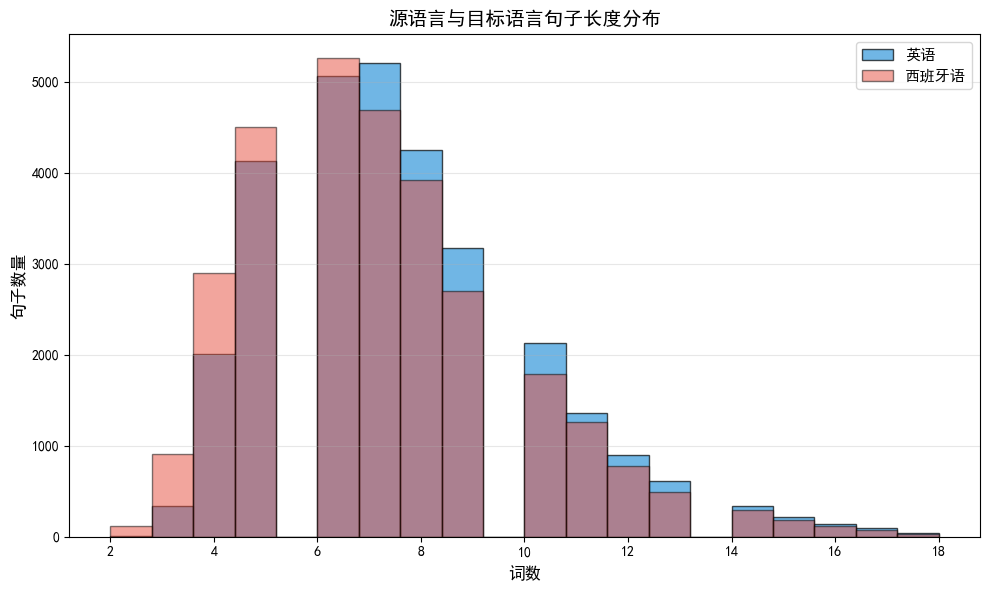

图1已保存: eda_sentence_length_distribution.png


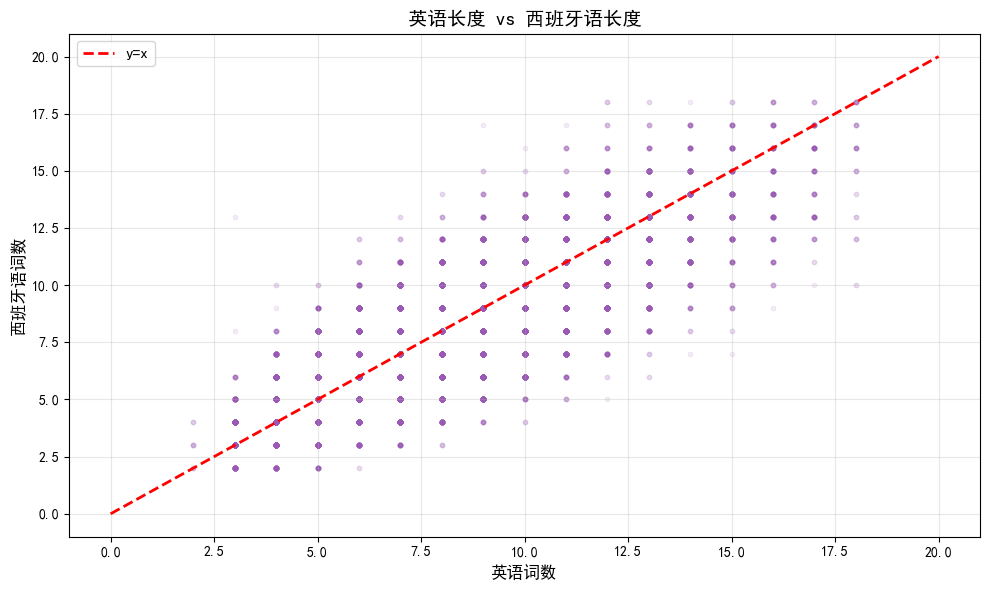

图2已保存: eda_length_correlation.png

英语句子平均长度: 7.5 词
西班牙语句子平均长度: 7.2 词

EDA 图表已保存:
  1. eda_sentence_length_distribution.png - 句子长度分布
  2. eda_length_correlation.png - 长度相关性散点图

BLEU评估函数定义完成（corpus BLEU + smoothing）。


In [5]:
# ============================================================================
# 第4部分：EDA 与 BLEU评价指标
# ============================================================================

# --- 4.1 句子长度分布 ---
eng_lengths = [len(eng.split()) for eng, _ in filtered_pairs]
spa_lengths = [len(spa.split()) for _, spa in filtered_pairs]

# 图1: 句子长度分布直方图
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.hist(eng_lengths, bins=20, color='#3498db', alpha=0.7, edgecolor='black', label='英语')
ax1.hist(spa_lengths, bins=20, color='#e74c3c', alpha=0.5, edgecolor='black', label='西班牙语')
ax1.set_title('源语言与目标语言句子长度分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('词数', fontsize=12)
ax1.set_ylabel('句子数量', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1已保存: eda_sentence_length_distribution.png")

# 图2: 英语 vs 西班牙语长度散点图
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(eng_lengths, spa_lengths, alpha=0.1, s=10, color='#9b59b6')
ax2.plot([0, 20], [0, 20], 'r--', linewidth=2, label='y=x')
ax2.set_title('英语长度 vs 西班牙语长度', fontsize=14, fontweight='bold')
ax2.set_xlabel('英语词数', fontsize=12)
ax2.set_ylabel('西班牙语词数', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_length_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2已保存: eda_length_correlation.png")

print()
print(f"英语句子平均长度: {np.mean(eng_lengths):.1f} 词")
print(f"西班牙语句子平均长度: {np.mean(spa_lengths):.1f} 词")

print()
print("=" * 50)
print("EDA 图表已保存:")
print("  1. eda_sentence_length_distribution.png - 句子长度分布")
print("  2. eda_length_correlation.png - 长度相关性散点图")
print("=" * 50)


# --- 4.2 标准 corpus BLEU（带平滑） ---
def _ids_to_bleu_tokens(ids):
    """将token id序列转为BLEU可用的token字符串序列"""
    if isinstance(ids, np.ndarray):
        ids = ids.tolist()
    return [str(int(tok)) for tok in ids]


def compute_bleu_scores(references, hypotheses, use_smoothing=True):
    """
    计算 corpus-level BLEU-1 / BLEU-2 / BLEU-4。

    参数:
        references: List[List[int]]，每条样本的参考翻译token id序列
        hypotheses: List[List[int]]，每条样本的模型翻译token id序列
        use_smoothing: 是否使用平滑，缓解高阶n-gram稀疏导致大量0分

    返回:
        dict: {'bleu1': float, 'bleu2': float, 'bleu4': float}
    """
    if len(references) == 0 or len(hypotheses) == 0:
        return {'bleu1': 0.0, 'bleu2': 0.0, 'bleu4': 0.0}

    refs_nltk = [[_ids_to_bleu_tokens(ref)] for ref in references]
    hyps_nltk = [_ids_to_bleu_tokens(hyp) for hyp in hypotheses]

    smoother = SmoothingFunction().method1 if use_smoothing else None

    bleu1 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoother
    )
    bleu2 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(0.5, 0.5, 0.0, 0.0),
        smoothing_function=smoother
    )
    bleu4 = nltk_corpus_bleu(
        refs_nltk, hyps_nltk,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoother
    )

    return {'bleu1': bleu1, 'bleu2': bleu2, 'bleu4': bleu4}


print()
print("BLEU评估函数定义完成（corpus BLEU + smoothing）。")

## 第5部分：模型1 - Seq2Seq + Attention (GRU)

### 编码器-解码器架构
- **编码器 (Encoder)**: 将源语言句子编码为上下文向量
- **解码器 (Decoder)**: 根据上下文向量逐词生成目标语言翻译
- **注意力机制 (Bahdanau Attention)**: 解码每个词时，动态关注源句子的不同部分

### Teacher Forcing
训练时以一定概率使用真实标签（而非模型预测）作为解码器下一步的输入，加速收敛。

### 网络结构
```
Encoder: 英语句子 → Embedding → GRU → 编码器隐状态序列
Attention: 解码器隐状态 × 编码器隐状态序列 → 注意力权重 → 上下文向量
Decoder: <sos> → Embedding → GRU(上下文向量) → FC → 逐词生成西班牙语
```

In [6]:
# ============================================================================
# 第5部分：Seq2Seq + Attention 模型定义
# ============================================================================

class Encoder(nn.Module):
    """
    GRU编码器：将源语言句子编码为隐状态序列
    
    输入: 源语言词索引序列 (batch, src_len)
    输出: 
        outputs: 每个时间步的隐状态 (batch, src_len, hidden_dim)  → 供注意力机制使用
        hidden:  最后时间步的隐状态 (1, batch, hidden_dim)        → 初始化解码器
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    
    def forward(self, x):
        embedded = self.embedding(x)           # (batch, src_len, embed_dim)
        outputs, hidden = self.gru(embedded)   # outputs: (batch, src_len, hidden)
        return outputs, hidden


class BahdanauAttention(nn.Module):
    """
    Bahdanau注意力机制（加性注意力）
    
    核心思想: 解码每个目标词时，不是只看编码器的最终隐状态，
    而是动态计算对源句子每个位置的"关注程度"（注意力权重），
    然后加权求和得到上下文向量。
    
    公式:
        score(s_t, h_i) = V^T × tanh(W1 × s_t + W2 × h_i)
        α_i = softmax(score_i)
        context = Σ α_i × h_i
    
    其中:
        s_t: 解码器当前隐状态
        h_i: 编码器第i个位置的隐状态
        α_i: 第i个位置的注意力权重
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)  # 处理解码器隐状态
        self.W2 = nn.Linear(hidden_dim, hidden_dim)  # 处理编码器输出
        self.V  = nn.Linear(hidden_dim, 1)            # 输出注意力分数
    
    def forward(self, decoder_hidden, encoder_outputs):
        """
        参数:
            decoder_hidden:  (batch, 1, hidden)  解码器当前隐状态
            encoder_outputs: (batch, src_len, hidden)  编码器所有隐状态
        
        返回:
            context: (batch, 1, hidden)  上下文向量
            attn_weights: (batch, src_len)  注意力权重（可用于可视化）
        """
        # 计算注意力分数
        score = self.V(torch.tanh(
            self.W1(decoder_hidden) + self.W2(encoder_outputs)
        ))  # (batch, src_len, 1)
        
        attn_weights = F.softmax(score.squeeze(2), dim=1)  # (batch, src_len)
        
        # 加权求和得到上下文向量
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (batch, 1, hidden)
        
        return context, attn_weights


class Decoder(nn.Module):
    """
    GRU解码器 + 注意力机制：逐词生成目标语言翻译
    
    每个时间步:
        1. 将当前输入词嵌入
        2. 用注意力机制计算上下文向量
        3. 将嵌入和上下文向量拼接，输入GRU
        4. 通过全连接层预测下一个词
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = BahdanauAttention(hidden_dim)
        # GRU输入 = 词嵌入 + 上下文向量
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        # 输出层: 预测目标词表中每个词的概率
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden, encoder_outputs):
        """
        解码一个时间步
        
        参数:
            x: (batch,) 当前输入词索引
            hidden: (1, batch, hidden) 解码器隐状态
            encoder_outputs: (batch, src_len, hidden) 编码器输出
        
        返回:
            output: (batch, vocab_size) 下一个词的概率分布
            hidden: (1, batch, hidden) 更新后的隐状态
            attn_weights: (batch, src_len) 注意力权重
        """
        embedded = self.embedding(x).unsqueeze(1)  # (batch, 1, embed)
        
        # 注意力: 用当前隐状态查询编码器输出
        context, attn_weights = self.attention(
            hidden.permute(1, 0, 2),  # (batch, 1, hidden)
            encoder_outputs
        )
        
        # 拼接嵌入和上下文向量
        gru_input = torch.cat([embedded, context], dim=2)  # (batch, 1, embed+hidden)
        
        output, hidden = self.gru(gru_input, hidden)
        output = self.fc(output.squeeze(1))  # (batch, vocab_size)
        
        return output, hidden, attn_weights


class Seq2Seq(nn.Module):
    """
    完整的Seq2Seq模型：编码器 + 解码器 + 注意力
    """
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        参数:
            src: (batch, src_len) 源语言序列
            trg: (batch, trg_len) 目标语言序列
            teacher_forcing_ratio: Teacher Forcing概率
        
        返回:
            outputs: (batch, trg_len, vocab_size) 每个位置的预测概率
        """
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc.out_features
        
        # 存储每个时间步的输出
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(DEVICE)
        
        # 编码
        encoder_outputs, hidden = self.encoder(src)
        
        # 解码器第一个输入是<sos>
        decoder_input = trg[:, 0]  # (batch,) 全是SOS_IDX
        
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs)
            outputs[:, t, :] = output
            
            # Teacher Forcing: 以一定概率使用真实标签作为下一步输入
            use_teacher_forcing = random.random() < teacher_forcing_ratio
            if use_teacher_forcing:
                decoder_input = trg[:, t]  # 使用真实标签
            else:
                decoder_input = output.argmax(dim=1)  # 使用模型预测
        
        return outputs


# --- 初始化模型 ---
encoder = Encoder(eng_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM)
decoder = Decoder(spa_vocab.n_words, EMBEDDING_DIM, HIDDEN_DIM)
model_seq2seq = Seq2Seq(encoder, decoder).to(DEVICE)

print(f"Seq2Seq+Attention 参数量: {sum(p.numel() for p in model_seq2seq.parameters()):,}")
print(f"  编码器: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"  解码器: {sum(p.numel() for p in decoder.parameters()):,}")

Seq2Seq+Attention 参数量: 10,167,453
  编码器: 2,403,840
  解码器: 7,763,613


In [7]:
# --- 5.2 训练与评估Seq2Seq ---
criterion_s2s = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # 忽略<pad>位置的损失
optimizer_s2s = optim.Adam(model_seq2seq.parameters(), lr=LEARNING_RATE)

def train_seq2seq_epoch(model, loader, criterion, optimizer):
    """训练Seq2Seq一个epoch"""
    model.train()
    total_loss = 0
    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()

        # 前向传播
        output = model(src, trg, TEACHER_FORCING_RATIO)
        # output: (batch, trg_len, vocab_size)
        # 需要reshape为 (batch*trg_len, vocab_size) 来计算CrossEntropyLoss
        output = output[:, 1:, :].reshape(-1, output.size(-1))  # 去掉第一个时间步（<sos>）
        trg = trg[:, 1:].reshape(-1)  # 对应的真实标签

        loss = criterion(output, trg)
        loss.backward()
        # 梯度裁剪: 防止RNN中的梯度爆炸
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def translate_sentence_greedy(model, src_tensor, max_len=MAX_SEQ_LEN):
    """Greedy解码：每一步都选最大概率token"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)  # (1, src_len)
        encoder_outputs, hidden = model.encoder(src)

        decoder_input = torch.tensor([SOS_IDX], device=DEVICE)
        translated_ids = []

        for _ in range(max_len):
            output, hidden, _ = model.decoder(decoder_input, hidden, encoder_outputs)
            predicted_id = output.argmax(dim=1).item()

            if predicted_id == EOS_IDX:
                break
            translated_ids.append(predicted_id)
            decoder_input = torch.tensor([predicted_id], device=DEVICE)

    return translated_ids


def translate_sentence_beam(model, src_tensor, beam_size=BEAM_SIZE,
                            length_penalty=LENGTH_PENALTY, max_len=MAX_SEQ_LEN):
    """
    Beam Search解码（batch=1）。

    评分函数:
        score = log_prob / (length ** length_penalty)
    """
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        encoder_outputs, hidden = model.encoder(src)

        # beam元素: (token_ids, hidden_state, cumulative_log_prob, finished)
        beams = [([SOS_IDX], hidden, 0.0, False)]

        for _ in range(max_len):
            candidates = []

            for token_ids, h, cum_log_prob, finished in beams:
                if finished:
                    candidates.append((token_ids, h, cum_log_prob, True))
                    continue

                decoder_input = torch.tensor([token_ids[-1]], device=DEVICE)
                output, next_hidden, _ = model.decoder(decoder_input, h, encoder_outputs)

                log_probs = F.log_softmax(output, dim=1).squeeze(0)  # (vocab_size,)
                topk_log_probs, topk_ids = torch.topk(log_probs, k=beam_size)

                for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_ids = token_ids + [idx]
                    new_finished = (idx == EOS_IDX)
                    candidates.append((new_ids, next_hidden.clone(), cum_log_prob + lp, new_finished))

            def beam_score(item):
                token_ids, _, cum_log_prob, _ = item
                length = max(len(token_ids) - 1, 1)  # 不把<sos>算进长度
                return cum_log_prob / (length ** length_penalty)

            beams = sorted(candidates, key=beam_score, reverse=True)[:beam_size]

            # 全部beam都已结束，提前停止
            if all(finished for _, _, _, finished in beams):
                break

        best_ids = beams[0][0]  # 最高分beam

        # 去掉<sos>并在<eos>处截断
        translated_ids = []
        for idx in best_ids[1:]:
            if idx == EOS_IDX:
                break
            translated_ids.append(idx)

        return translated_ids


def evaluate_bleu(model, test_data_eng, test_data_spa, decode_method='beam'):
    """在测试集上计算BLEU-1/2/4"""
    references = []
    hypotheses = []

    for i in range(len(test_data_eng)):
        src_tensor = torch.tensor(test_data_eng[i], dtype=torch.long)

        if decode_method == 'beam':
            translated_ids = translate_sentence_beam(model, src_tensor)
        else:
            translated_ids = translate_sentence_greedy(model, src_tensor)

        # 参考翻译: 去掉<sos>, <eos>, <pad>
        ref_ids = [idx for idx in test_data_spa[i] if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)]

        references.append(ref_ids)
        hypotheses.append(translated_ids)

    return compute_bleu_scores(references, hypotheses, use_smoothing=True)


# --- 训练循环 ---
history_s2s = {'train_loss': [], 'bleu1': [], 'bleu2': [], 'bleu4': []}

print()
print('=' * 50)
print('开始训练 Seq2Seq + Attention')
print('=' * 50)

for epoch in range(EPOCHS_SEQ2SEQ):
    t0 = time.time()
    train_loss = train_seq2seq_epoch(model_seq2seq, train_loader, criterion_s2s, optimizer_s2s)

    should_eval = ((epoch + 1) % BLEU_EVAL_EVERY == 0) or (epoch == 0)
    if should_eval:
        bleu_scores = evaluate_bleu(model_seq2seq, eng_test, spa_test, decode_method='beam')
        b1, b2, b4 = bleu_scores['bleu1'], bleu_scores['bleu2'], bleu_scores['bleu4']
        history_s2s['bleu1'].append(b1)
        history_s2s['bleu2'].append(b2)
        history_s2s['bleu4'].append(b4)
        bleu_msg = f'BLEU-1: {b1:.4f} - BLEU-2: {b2:.4f} - BLEU-4: {b4:.4f}'
    else:
        history_s2s['bleu1'].append(np.nan)
        history_s2s['bleu2'].append(np.nan)
        history_s2s['bleu4'].append(np.nan)
        bleu_msg = 'BLEU: N/A'

    elapsed = time.time() - t0
    history_s2s['train_loss'].append(train_loss)

    print(f'Epoch {epoch+1}/{EPOCHS_SEQ2SEQ} - Loss: {train_loss:.4f} - {bleu_msg} - 耗时: {elapsed:.1f}s')

# 最终BLEU（使用Beam Search）
final_s2s = evaluate_bleu(model_seq2seq, eng_test, spa_test, decode_method='beam')
s2s_bleu1 = final_s2s['bleu1']
s2s_bleu2 = final_s2s['bleu2']
s2s_bleu4 = final_s2s['bleu4']
s2s_bleu = s2s_bleu4  # 兼容后续代码中的变量名

print()
print(f'Seq2Seq+Attention 最终BLEU-1: {s2s_bleu1:.4f}')
print(f'Seq2Seq+Attention 最终BLEU-2: {s2s_bleu2:.4f}')
print(f'Seq2Seq+Attention 最终BLEU-4: {s2s_bleu4:.4f}')
if torch.cuda.is_available():
    torch.cuda.empty_cache()


开始训练 Seq2Seq + Attention
Epoch 1/20 - Loss: 5.1718 - BLEU-1: 0.3488 - BLEU-2: 0.1325 - BLEU-4: 0.0246 - 耗时: 149.5s
Epoch 2/20 - Loss: 4.0551 - BLEU: N/A - 耗时: 41.5s
Epoch 3/20 - Loss: 3.3369 - BLEU: N/A - 耗时: 42.5s
Epoch 4/20 - Loss: 2.7650 - BLEU: N/A - 耗时: 39.8s
Epoch 5/20 - Loss: 2.3034 - BLEU-1: 0.5677 - BLEU-2: 0.3968 - BLEU-4: 0.2066 - 耗时: 170.8s
Epoch 6/20 - Loss: 1.9286 - BLEU: N/A - 耗时: 36.1s
Epoch 7/20 - Loss: 1.5962 - BLEU: N/A - 耗时: 37.4s
Epoch 8/20 - Loss: 1.3403 - BLEU: N/A - 耗时: 37.2s
Epoch 9/20 - Loss: 1.1163 - BLEU: N/A - 耗时: 36.1s
Epoch 10/20 - Loss: 0.9393 - BLEU-1: 0.6137 - BLEU-2: 0.4568 - BLEU-4: 0.2670 - 耗时: 170.9s
Epoch 11/20 - Loss: 0.8033 - BLEU: N/A - 耗时: 37.5s
Epoch 12/20 - Loss: 0.6910 - BLEU: N/A - 耗时: 36.1s
Epoch 13/20 - Loss: 0.5987 - BLEU: N/A - 耗时: 36.3s
Epoch 14/20 - Loss: 0.5223 - BLEU: N/A - 耗时: 36.4s
Epoch 15/20 - Loss: 0.4559 - BLEU-1: 0.6174 - BLEU-2: 0.4578 - BLEU-4: 0.2656 - 耗时: 174.4s
Epoch 16/20 - Loss: 0.3860 - BLEU: N/A - 耗时: 37.9s
Epoch 1

In [8]:
# --- 5.3 Seq2Seq 翻译示例展示 ---
print("=" * 60)
print("Seq2Seq + Attention 翻译示例（Beam Search）")
print("=" * 60)

# 随机选取10条测试集句子展示翻译效果
sample_indices = random.sample(range(len(eng_test)), 10)

for idx in sample_indices:
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    translated_ids_beam = translate_sentence_beam(model_seq2seq, src_tensor)

    # 还原文本
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    hyp_text_beam = spa_vocab.decode_sequence(translated_ids_beam)

    print(f"  英语原文:   {src_text}")
    print(f"  参考翻译:   {ref_text}")
    print(f"  Beam翻译:   {hyp_text_beam}")
    print()


Seq2Seq + Attention 翻译示例（Beam Search）
  英语原文:   tom sometimes has trouble understanding other people s feelings .
  参考翻译:   tom a veces tiene dificultad para comprender los sentimientos ajenos .
  Beam翻译:   tom tiene problemas problemas para problemas la gente .

  英语原文:   do you believe in ghosts ?
  参考翻译:   ¿ cree usted en los fantasmas ?
  Beam翻译:   ¿ crees en los fantasmas ?

  英语原文:   don t pay attention to him .
  参考翻译:   no le hagas caso .
  Beam翻译:   no hagas atención a él .

  英语原文:   i reserved my hotel room three weeks in advance .
  参考翻译:   reservé mi habitación en el hotel con tres semanas de antelación .
  Beam翻译:   me perdí mi habitación en tres años .

  英语原文:   i want to give you a goodbye kiss .
  参考翻译:   quiero darte un beso de despedida .
  Beam翻译:   quiero dar un buen sitio .

  英语原文:   it is bad manners to speak with your mouth full .
  参考翻译:   es de mala educación hablar con la boca llena .
  Beam翻译:   es se está a hablar con con la boca llena .

  英语原文:   i want

## 第6部分：模型2 - Transformer 翻译模型

### 与分类任务Transformer的区别
- 分类任务只用 Encoder，翻译任务需要 Encoder + Decoder
- Decoder中有两种注意力：
  - **自注意力 (Self-Attention)**: 目标序列内部的注意力
  - **交叉注意力 (Cross-Attention)**: 目标序列对源序列的注意力
- Decoder使用因果掩码 (Causal Mask)，防止"偷看"未来的词

### 网络结构
```
Encoder: 英语 → Embedding + PosEnc → N × EncoderLayer → memory
Decoder: 西班牙语 → Embedding + PosEnc → N × DecoderLayer(self-attn + cross-attn) → FC → 词概率
```

In [9]:
# ============================================================================
# 第6部分：Transformer 翻译模型
# ============================================================================

class PositionalEncoding(nn.Module):
    """位置编码（与分类任务中相同）"""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerTranslator(nn.Module):
    """
    基于Transformer的机器翻译模型（完整Encoder-Decoder架构）
    
    与分类任务Transformer的关键区别:
        1. 使用完整的Encoder-Decoder结构（分类只用Encoder）
        2. Decoder有因果掩码（Causal Mask），防止看到未来的词
        3. Decoder有交叉注意力（Cross-Attention），关注源语言
    
    参数:
        src_vocab_size: 源语言词表大小
        trg_vocab_size: 目标语言词表大小
        d_model:        模型维度
        nhead:          多头注意力头数
        num_layers:     编码器/解码器层数
        dim_ff:         前馈网络维度
    """
    def __init__(self, src_vocab_size, trg_vocab_size, d_model=HIDDEN_DIM,
                 nhead=NUM_HEADS, num_layers=NUM_LAYERS, dim_ff=FF_DIM):
        super().__init__()
        
        # 源语言和目标语言各自的Embedding
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # PyTorch内置的Transformer模块
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_ff,
            dropout=0.1,
            batch_first=True
        )
        
        # 输出层: 将Transformer输出映射到目标词表大小
        self.fc_out = nn.Linear(d_model, trg_vocab_size)
        self.d_model = d_model
    
    def forward(self, src, trg):
        """
        参数:
            src: (batch, src_len) 源语言序列
            trg: (batch, trg_len) 目标语言序列（训练时使用Teacher Forcing）
        """
        # --- 生成掩码 ---
        # 因果掩码: 上三角矩阵，防止Decoder看到未来的词
        trg_len = trg.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(trg_len).to(DEVICE)
        
        # Padding掩码: 告诉模型哪些位置是padding
        src_pad_mask = (src == PAD_IDX)  # (batch, src_len)
        trg_pad_mask = (trg == PAD_IDX)  # (batch, trg_len)
        
        # --- Embedding + 位置编码 ---
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        trg_emb = self.pos_encoder(self.trg_embedding(trg) * math.sqrt(self.d_model))
        
        # --- Transformer前向传播 ---
        output = self.transformer(
            src_emb, trg_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=trg_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )
        
        return self.fc_out(output)  # (batch, trg_len, trg_vocab_size)


# --- 初始化 ---
model_tf = TransformerTranslator(eng_vocab.n_words, spa_vocab.n_words).to(DEVICE)
print(f"Transformer翻译模型 参数量: {sum(p.numel() for p in model_tf.parameters()):,}")

Transformer翻译模型 参数量: 11,686,300


In [10]:
# ============================================================================
# 第6部分（全面优化版）：Transformer 训练与评估
# ============================================================================

import sys

# --- 6.2.1 优化的学习率调度器 ---
class WarmupScheduler:
    """
    优化的学习率调度器
    - 前 warmup_steps 步线性增加
    - 之后保持恒定
    """
    def __init__(self, optimizer, warmup_steps=4000, max_lr=0.001):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0
        
    def step(self):
        self.step_num += 1
        lr = self._get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
    
    def _get_lr(self):
        if self.step_num < self.warmup_steps:
            return self.max_lr * (self.step_num / self.warmup_steps)
        else:
            return self.max_lr


# --- 6.2.2 Transformer Beam Search 解码（优化版）---
def translate_sentence_tf_beam(model, src_tensor, beam_size=BEAM_SIZE,
                                length_penalty=LENGTH_PENALTY, max_len=MAX_SEQ_LEN):
    """Transformer Beam Search 解码"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        beams = [([SOS_IDX], 0.0, False)]
        
        for _ in range(max_len):
            candidates = []
            
            for token_ids, cum_log_prob, finished in beams:
                if finished:
                    candidates.append((token_ids, cum_log_prob, True))
                    continue
                
                trg_tensor = torch.tensor([token_ids], dtype=torch.long).to(DEVICE)
                output = model(src, trg_tensor)
                log_probs = F.log_softmax(output[0, -1, :], dim=0)
                topk_log_probs, topk_ids = torch.topk(log_probs, k=beam_size)
                
                for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                    new_ids = token_ids + [idx]
                    new_finished = (idx == EOS_IDX)
                    candidates.append((new_ids, cum_log_prob + lp, new_finished))
            
            def beam_score(item):
                token_ids, cum_log_prob, _ = item
                length = max(len(token_ids) - 1, 1)
                return cum_log_prob / (length ** length_penalty)
            
            beams = sorted(candidates, key=beam_score, reverse=True)[:beam_size]
            
            if all(finished for _, _, finished in beams):
                break
        
        best_ids = beams[0][0]
        translated_ids = []
        for idx in best_ids[1:]:
            if idx == EOS_IDX:
                break
            translated_ids.append(idx)
        
        return translated_ids


# --- 6.2.3 训练与评估函数 ---
criterion_tf = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer_tf = optim.Adam(model_tf.parameters(), lr=0.001, betas=(0.9, 0.98), eps=1e-9)
scheduler_tf = WarmupScheduler(optimizer_tf, warmup_steps=4000, max_lr=0.001)

def train_transformer_epoch(model, loader, criterion, optimizer, scheduler):
    """训练 Transformer 一个 epoch"""
    model.train()
    total_loss = 0
    for src, trg in loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        
        trg_input = trg[:, :-1]
        trg_target = trg[:, 1:]
        
        output = model(src, trg_input)
        output = output.reshape(-1, output.size(-1))
        trg_target = trg_target.reshape(-1)
        
        loss = criterion(output, trg_target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def translate_sentence_tf_greedy(model, src_tensor, max_len=MAX_SEQ_LEN):
    """Transformer 贪心解码"""
    model.eval()
    with torch.no_grad():
        src = src_tensor.unsqueeze(0).to(DEVICE)
        trg_ids = [SOS_IDX]
        
        for _ in range(max_len):
            trg_tensor = torch.tensor([trg_ids], dtype=torch.long).to(DEVICE)
            output = model(src, trg_tensor)
            next_token = output[0, -1, :].argmax().item()
            
            if next_token == EOS_IDX:
                break
            trg_ids.append(next_token)
        
        return trg_ids[1:]


def evaluate_bleu_tf(model, test_data_eng, test_data_spa, decode_method='beam', sample_size=None):
    """
    在测试集上计算 Transformer 的 BLEU-1/2/4
    
    参数:
        sample_size: None 表示使用全部数据，否则随机采样指定数量
    """
    references = []
    hypotheses = []
    
    if sample_size is not None and sample_size < len(test_data_eng):
        indices = random.sample(range(len(test_data_eng)), sample_size)
    else:
        indices = range(len(test_data_eng))
    
    for i in indices:
        src_tensor = torch.tensor(test_data_eng[i], dtype=torch.long)
        
        if decode_method == 'beam':
            translated_ids = translate_sentence_tf_beam(model, src_tensor)
        else:
            translated_ids = translate_sentence_tf_greedy(model, src_tensor)
        
        ref_ids = [idx for idx in test_data_spa[i] if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        references.append(ref_ids)
        hypotheses.append(translated_ids)
    
    return compute_bleu_scores(references, hypotheses, use_smoothing=True)


# --- 6.2.4 训练循环 ---
history_tf = {'train_loss': [], 'bleu1': [], 'bleu2': [], 'bleu4': []}

print()
print('=' * 50)
print('开始训练 Transformer（优化版）')
print('=' * 50)
print('优化策略：')
print('  1. 修复学习率调度器')
print('  2. 训练时快速评估（500样本），最终完整评估（3000样本）')
print('  3. 使用 Beam Search 提升翻译质量')
sys.stdout.flush()

for epoch in range(EPOCHS_TF):
    t0 = time.time()
    
    print(f'Epoch {epoch+1}/{EPOCHS_TF} - 训练中...', end='', flush=True)
    train_loss = train_transformer_epoch(model_tf, train_loader, criterion_tf, optimizer_tf, scheduler_tf)
    print(f' Loss: {train_loss:.4f}', end='', flush=True)
    
    # 每 5 个 epoch 或第 1 个 epoch 评估（使用 500 样本快速评估）
    should_eval = ((epoch + 1) % BLEU_EVAL_EVERY == 0) or (epoch == 0)
    if should_eval:
        print(' - 评估中...', end='', flush=True)
        bleu_scores = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='beam', sample_size=500)
        b1, b2, b4 = bleu_scores['bleu1'], bleu_scores['bleu2'], bleu_scores['bleu4']
        history_tf['bleu1'].append(b1)
        history_tf['bleu2'].append(b2)
        history_tf['bleu4'].append(b4)
        bleu_msg = f' BLEU-1: {b1:.4f} - BLEU-2: {b2:.4f} - BLEU-4: {b4:.4f}'
    else:
        history_tf['bleu1'].append(np.nan)
        history_tf['bleu2'].append(np.nan)
        history_tf['bleu4'].append(np.nan)
        bleu_msg = ' BLEU: N/A'
    
    elapsed = time.time() - t0
    history_tf['train_loss'].append(train_loss)
    
    current_lr = optimizer_tf.param_groups[0]['lr']
    print(f' - LR: {current_lr:.6f} -{bleu_msg} - 耗时: {elapsed:.1f}s')
    sys.stdout.flush()

# --- 最终完整评估（使用全部 3000 个测试样本）---
print()
print('=' * 50)
print('最终评估（全部 3000 个测试样本，Beam Search）')
print('=' * 50)
sys.stdout.flush()

tf_final = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='beam', sample_size=None)
tf_bleu1 = tf_final['bleu1']
tf_bleu2 = tf_final['bleu2']
tf_bleu4 = tf_final['bleu4']
tf_bleu = tf_bleu4  # 兼容后续代码

print(f'Transformer (Beam Search) - BLEU-1: {tf_bleu1:.4f}')
print(f'Transformer (Beam Search) - BLEU-2: {tf_bleu2:.4f}')
print(f'Transformer (Beam Search) - BLEU-4: {tf_bleu4:.4f}')

# --- Greedy vs Beam Search 对比 ---
print()
print('=' * 50)
print('解码策略对比（全部 3000 个测试样本）')
print('=' * 50)
sys.stdout.flush()

greedy_scores = evaluate_bleu_tf(model_tf, eng_test, spa_test, decode_method='greedy', sample_size=None)
print(f'Greedy 解码  - BLEU-1: {greedy_scores["bleu1"]:.4f} - BLEU-2: {greedy_scores["bleu2"]:.4f} - BLEU-4: {greedy_scores["bleu4"]:.4f}')
print(f'Beam Search  - BLEU-1: {tf_bleu1:.4f} - BLEU-2: {tf_bleu2:.4f} - BLEU-4: {tf_bleu4:.4f}')
print(f'提升幅度     - BLEU-1: +{(tf_bleu1 - greedy_scores["bleu1"]):.4f} - BLEU-2: +{(tf_bleu2 - greedy_scores["bleu2"]):.4f} - BLEU-4: +{(tf_bleu4 - greedy_scores["bleu4"]):.4f}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print()
print('Transformer 训练完成！')
sys.stdout.flush()


开始训练 Transformer（优化版）
优化策略：
  1. 修复学习率调度器
  2. 训练时快速评估（500样本），最终完整评估（3000样本）
  3. 使用 Beam Search 提升翻译质量
Epoch 1/20 - 训练中... Loss: 6.6504 - 评估中... - LR: 0.000106 - BLEU-1: 0.2598 - BLEU-2: 0.0644 - BLEU-4: 0.0039 - 耗时: 161.4s
Epoch 2/20 - 训练中... Loss: 4.6602 - LR: 0.000211 - BLEU: N/A - 耗时: 11.6s
Epoch 3/20 - 训练中... Loss: 3.9599 - LR: 0.000316 - BLEU: N/A - 耗时: 12.3s
Epoch 4/20 - 训练中... Loss: 3.4585 - LR: 0.000422 - BLEU: N/A - 耗时: 11.9s
Epoch 5/20 - 训练中... Loss: 3.0573 - 评估中... - LR: 0.000527 - BLEU-1: 0.4756 - BLEU-2: 0.3053 - BLEU-4: 0.1277 - 耗时: 141.9s
Epoch 6/20 - 训练中... Loss: 2.7242 - LR: 0.000633 - BLEU: N/A - 耗时: 11.4s
Epoch 7/20 - 训练中... Loss: 2.4541 - LR: 0.000739 - BLEU: N/A - 耗时: 12.0s
Epoch 8/20 - 训练中... Loss: 2.2412 - LR: 0.000844 - BLEU: N/A - 耗时: 11.9s
Epoch 9/20 - 训练中... Loss: 2.0782 - LR: 0.000950 - BLEU: N/A - 耗时: 12.1s
Epoch 10/20 - 训练中... Loss: 1.9377 - 评估中... - LR: 0.001000 - BLEU-1: 0.5015 - BLEU-2: 0.3519 - BLEU-4: 0.1949 - 耗时: 137.0s
Epoch 11/20 - 训练中... Loss: 

In [11]:
# --- 6.3 Transformer 翻译示例展示 ---
print("=" * 60)
print("Transformer 翻译示例（Beam Search）")
print("=" * 60)

# 使用与 Seq2Seq 相同的样本索引，方便对比
for idx in sample_indices:
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    translated_ids = translate_sentence_tf_beam(model_tf, src_tensor)
    
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    hyp_text = spa_vocab.decode_sequence(translated_ids)
    
    print(f"  英语原文:   {src_text}")
    print(f"  参考翻译:   {ref_text}")
    print(f"  模型翻译:   {hyp_text}")
    print()

Transformer 翻译示例（Beam Search）
  英语原文:   tom sometimes has trouble understanding other people s feelings .
  参考翻译:   tom a veces tiene dificultad para comprender los sentimientos ajenos .
  模型翻译:   a veces la gente tiene problemas por los otros .

  英语原文:   do you believe in ghosts ?
  参考翻译:   ¿ cree usted en los fantasmas ?
  模型翻译:   ¿ crees en los fantasmas ?

  英语原文:   don t pay attention to him .
  参考翻译:   no le hagas caso .
  模型翻译:   no atención a atención .

  英语原文:   i reserved my hotel room three weeks in advance .
  参考翻译:   reservé mi habitación en el hotel con tres semanas de antelación .
  模型翻译:   mis semanas de libros en el hotel .

  英语原文:   i want to give you a goodbye kiss .
  参考翻译:   quiero darte un beso de despedida .
  模型翻译:   quiero dar un beso .

  英语原文:   it is bad manners to speak with your mouth full .
  参考翻译:   es de mala educación hablar con la boca llena .
  模型翻译:   es malo para hablar con tu boca .

  英语原文:   i want you to understand what i m trying to say .
 

## 第7部分：实验结果对比与可视化

对比两个翻译模型的表现：
- **训练损失曲线**: 观察收敛速度和稳定性
- **BLEU分数对比**: 翻译质量的量化指标
- **翻译示例对比**: 直观感受翻译效果差异

实验结果汇总（两个模型均使用 Beam Search）
                        模型   BLEU-1   BLEU-2   BLEU-4      参数量
Seq2Seq + Attention (Beam) 0.607264 0.448574 0.259741 10167453
        Transformer (Beam) 0.582380 0.426517 0.249031 11686300



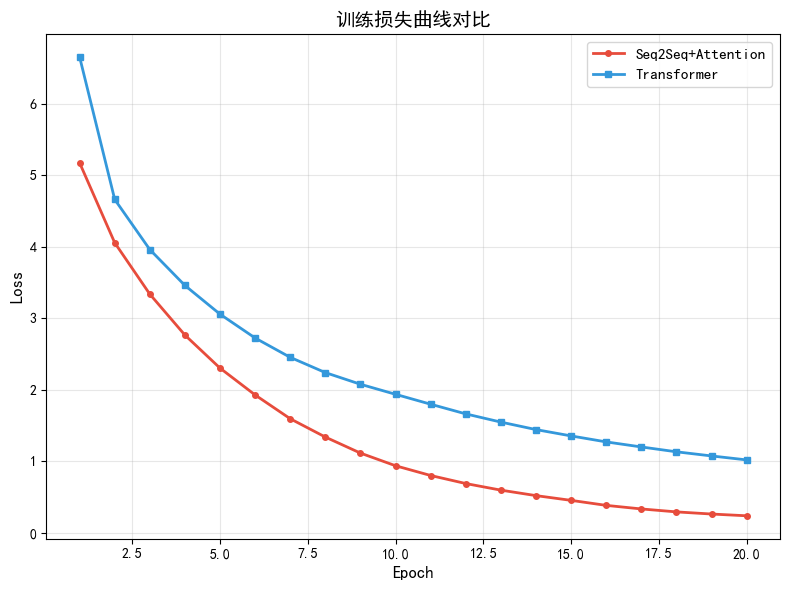

图1已保存: loss_comparison.png


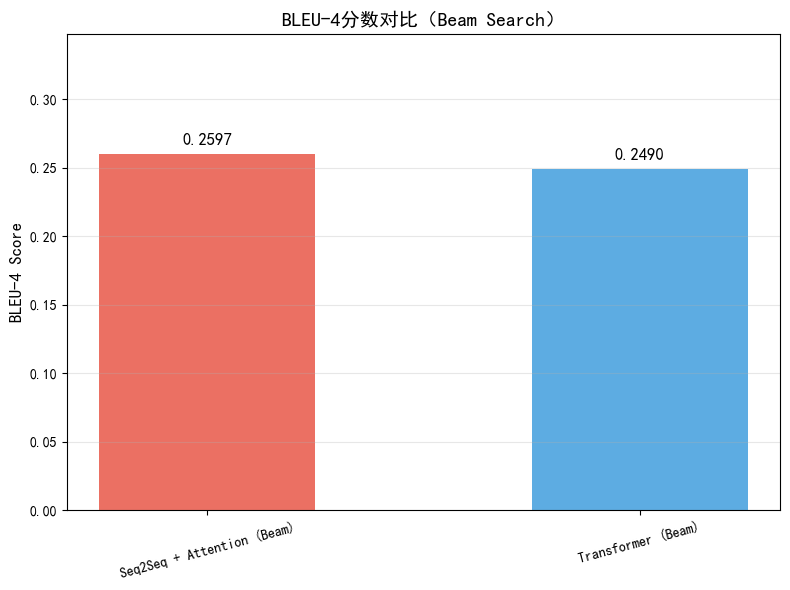

图2已保存: bleu4_comparison.png


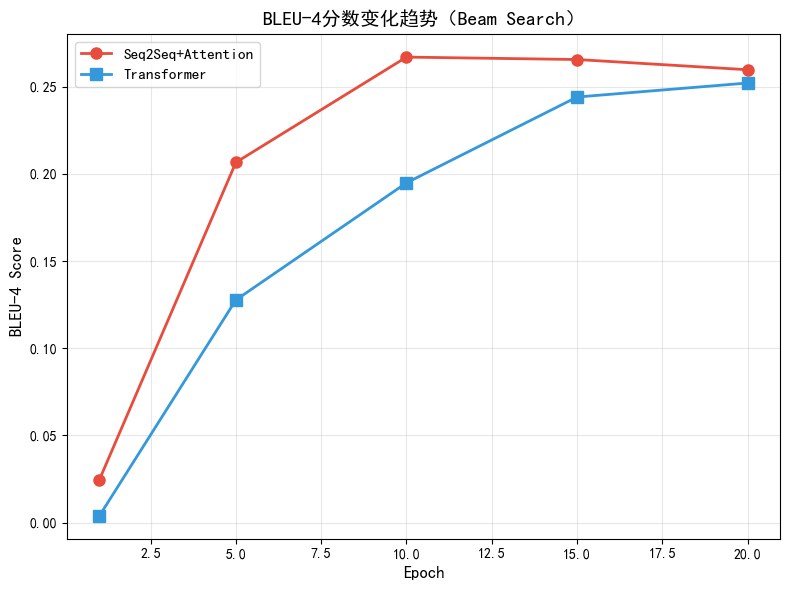

图3已保存: bleu4_trend.png

所有图表已保存:
  1. loss_comparison.png - 训练损失曲线对比
  2. bleu4_comparison.png - BLEU-4分数柱状图
  3. bleu4_trend.png - BLEU-4分数变化趋势


In [12]:
# ============================================================================
# 第7部分：实验结果对比与可视化
# ============================================================================

# --- 7.1 结果汇总表 ---
results = pd.DataFrame({
    '模型': ['Seq2Seq + Attention (Beam)', 'Transformer (Beam)'],
    'BLEU-1': [s2s_bleu1, tf_bleu1],
    'BLEU-2': [s2s_bleu2, tf_bleu2],
    'BLEU-4': [s2s_bleu4, tf_bleu4],
    '参数量': [
        sum(p.numel() for p in model_seq2seq.parameters()),
        sum(p.numel() for p in model_tf.parameters())
    ]
})
print("=" * 50)
print("实验结果汇总（两个模型均使用 Beam Search）")
print("=" * 50)
print(results.to_string(index=False))
print()

# --- 7.2 可视化（分开保存三张图）---

# 图1: 训练损失曲线对比
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(range(1, EPOCHS_SEQ2SEQ+1), history_s2s['train_loss'],
         'o-', label='Seq2Seq+Attention', color='#e74c3c', markersize=4, linewidth=2)
ax1.plot(range(1, EPOCHS_TF+1), history_tf['train_loss'],
         's-', label='Transformer', color='#3498db', markersize=4, linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('训练损失曲线对比', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1已保存: loss_comparison.png")

# 图2: BLEU-4分数柱状图
fig2, ax2 = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#3498db']
bars = ax2.bar(results['模型'], results['BLEU-4'], color=colors, width=0.5, alpha=0.8)
ax2.set_title('BLEU-4分数对比（Beam Search）', fontsize=14, fontweight='bold')
ax2.set_ylabel('BLEU-4 Score', fontsize=12)
ax2.set_ylim(0, max(results['BLEU-4']) * 1.3 + 0.01)
for bar, val in zip(bars, results['BLEU-4']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bleu4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2已保存: bleu4_comparison.png")

# 图3: BLEU-4随训练变化趋势
fig3, ax3 = plt.subplots(figsize=(8, 6))
epoch_axis_s2s = np.arange(1, EPOCHS_SEQ2SEQ + 1)
epoch_axis_tf = np.arange(1, EPOCHS_TF + 1)
bleu4_s2s = np.array(history_s2s['bleu4'], dtype=float)
bleu4_tf = np.array(history_tf['bleu4'], dtype=float)

valid_s2s = ~np.isnan(bleu4_s2s)
valid_tf = ~np.isnan(bleu4_tf)

ax3.plot(epoch_axis_s2s[valid_s2s], bleu4_s2s[valid_s2s], 'o-',
         label='Seq2Seq+Attention', color='#e74c3c', markersize=8, linewidth=2)
ax3.plot(epoch_axis_tf[valid_tf], bleu4_tf[valid_tf], 's-',
         label='Transformer', color='#3498db', markersize=8, linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('BLEU-4 Score', fontsize=12)
ax3.set_title('BLEU-4分数变化趋势（Beam Search）', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bleu4_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("图3已保存: bleu4_trend.png")

print()
print("=" * 50)
print("所有图表已保存:")
print("  1. loss_comparison.png - 训练损失曲线对比")
print("  2. bleu4_comparison.png - BLEU-4分数柱状图")
print("  3. bleu4_trend.png - BLEU-4分数变化趋势")
print("=" * 50)

In [13]:
# --- 7.3 两个模型翻译结果并排对比 ---
print("=" * 70)
print("两个模型翻译结果对比")
print("=" * 70)

compare_indices = random.sample(range(len(eng_test)), 8)

for i, idx in enumerate(compare_indices, 1):
    src_tensor = torch.tensor(eng_test[idx], dtype=torch.long)
    
    # 两个模型分别翻译（都使用 Beam Search）
    s2s_ids = translate_sentence_beam(model_seq2seq, src_tensor)
    tf_ids = translate_sentence_tf_beam(model_tf, src_tensor)
    
    src_text = eng_vocab.decode_sequence(eng_test[idx])
    ref_text = spa_vocab.decode_sequence(spa_test[idx])
    s2s_text = spa_vocab.decode_sequence(s2s_ids)
    tf_text = spa_vocab.decode_sequence(tf_ids)
    
    print(f"[{i}] 英语原文:        {src_text}")
    print(f"    参考翻译:        {ref_text}")
    print(f"    Seq2Seq+Attn:   {s2s_text}")
    print(f"    Transformer:    {tf_text}")
    print()

两个模型翻译结果对比
[1] 英语原文:        i need a doctor .
    参考翻译:        necesito un doctor .
    Seq2Seq+Attn:   necesito un doctor .
    Transformer:    necesito un doctor .

[2] 英语原文:        do you run every day ?
    参考翻译:        ¿ corres todos los días ?
    Seq2Seq+Attn:   ¿ todos los días ?
    Transformer:    ¿ haces este día ?

[3] 英语原文:        is tom interested ?
    参考翻译:        ¿ tom está interesado ?
    Seq2Seq+Attn:   ¿ está tom por tom ?
    Transformer:    ¿ tom está interesada ?

[4] 英语原文:        i ve got a cold .
    参考翻译:        estoy acatarrado .
    Seq2Seq+Attn:   estoy resfriado .
    Transformer:    tengo un frío .

[5] 英语原文:        the teacher distributed the leaflets .
    参考翻译:        el profesor repartió panfletos .
    Seq2Seq+Attn:   el profesor pasó a los jugadores .
    Transformer:    el profesor se detuvo por la profesora .

[6] 英语原文:        i m expecting a letter from her .
    参考翻译:        espero una carta suya .
    Seq2Seq+Attn:   espero una carta de ella .

In [31]:
print("变量检查:")
print(f"filtered_pairs: {'✓' if 'filtered_pairs' in dir() else '✗'}")
print(f"test_pairs: {'✓' if 'test_pairs' in dir() else '✗'}")
print(f"model_seq2seq: {'✓' if 'model_seq2seq' in dir() else '✗'}")
print(f"model_tf: {'✓' if 'model_tf' in dir() else '✗'}")
print(f"eng_vocab: {'✓' if 'eng_vocab' in dir() else '✗'}")
print(f"spa_vocab: {'✓' if 'spa_vocab' in dir() else '✗'}")
# 创建变量别名（适配第7章的变量命名）
seq2seq_model = model_seq2seq
transformer_model = model_tf

print("已创建变量别名:")
print(f"  seq2seq_model -> model_seq2seq ✓")
print(f"  transformer_model -> model_tf ✓")

# 在 7.4 节开头添加修复函数
def translate_with_attention(model, src_sentence, src_vocab, tgt_vocab, device, max_len=50):
    """
    翻译句子并返回注意力权重
    """
    model.eval()
    with torch.no_grad():
        if not src_sentence or not src_sentence.strip():
            return [], np.zeros((0, 0))

        # 分词并转换为索引（未知词使用 PAD_IDX=0）
        src_tokens = src_sentence.lower().split()
        src_indices = [src_vocab.word2idx.get(word, PAD_IDX) for word in src_tokens]
        src_indices = [SOS_IDX] + src_indices + [EOS_IDX]

        src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

        # 编码
        encoder_outputs, hidden = model.encoder(src_tensor)

        # 解码
        decoder_input = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        decoded_ids = []
        attention_weights = []

        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(
                decoder_input, hidden, encoder_outputs
            )
            
            topv, topi = output.topk(1)
            decoded_id = topi.item()
            
            if decoded_id == EOS_IDX:
                break
                
            decoded_ids.append(decoded_id)
            attention_weights.append(attn_weights.squeeze().cpu().numpy())
            decoder_input = topi.detach()

        # 转换为矩阵
        if attention_weights:
            attention_matrix = np.array(attention_weights)
        else:
            attention_matrix = np.zeros((0, len(src_indices)))

        return decoded_ids, attention_matrix

变量检查:
filtered_pairs: ✓
test_pairs: ✓
model_seq2seq: ✓
model_tf: ✓
eng_vocab: ✓
spa_vocab: ✓
已创建变量别名:
  seq2seq_model -> model_seq2seq ✓
  transformer_model -> model_tf ✓


In [32]:
# 修复版本：translate_with_attention（处理未知词使用 PAD_IDX）
def translate_with_attention(model, src_sentence, src_vocab, tgt_vocab, device, max_len=50):
    """
    翻译句子并返回注意力权重

    参数:
        model: Seq2Seq 模型
        src_sentence: 源语言句子 (字符串)
        src_vocab: 源语言词汇表
        tgt_vocab: 目标语言词汇表
        device: 设备
        max_len: 最大翻译长度

    返回:
        translated_ids: 翻译的索引列表
        attention_matrix: 注意力权重矩阵 (tgt_len, src_len)
    """
    model.eval()
    with torch.no_grad():
        try:
            if not src_sentence or not src_sentence.strip():
                return [], np.zeros((0, 0))

            # 分词并转换为索引（未知词使用 PAD_IDX=0，与训练时一致）
            src_tokens = src_sentence.lower().split()
            src_indices = [src_vocab.word2idx.get(word, PAD_IDX) for word in src_tokens]
            src_indices = [SOS_IDX] + src_indices + [EOS_IDX]

            src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)

            # 编码
            encoder_outputs, hidden = model.encoder(src_tensor)

            # 解码
            decoder_input = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
            translated_ids = []
            attention_weights = []

            for _ in range(max_len):
                output, hidden, attn_weights = model.decoder(
                    decoder_input, hidden, encoder_outputs
                )
                
                topv, topi = output.topk(1)
                decoded_id = topi.item()
                
                if decoded_id == EOS_IDX:
                    break
                    
                translated_ids.append(decoded_id)
                attention_weights.append(attn_weights.squeeze().cpu().numpy())
                decoder_input = topi.detach()

            # 转换为矩阵
            if attention_weights:
                attention_matrix = np.array(attention_weights)
            else:
                attention_matrix = np.zeros((0, len(src_indices)))

            return translated_ids, attention_matrix
            
        except Exception as e:
            print(f"翻译失败: {e}")
            return [], np.zeros((0, 0))


# 修复版本：translate_with_attention_tf（处理未知词使用 PAD_IDX）
def translate_with_attention_tf(model, src_sentence, src_vocab, tgt_vocab, max_len=50):
    """
    使用 Transformer 翻译句子并计算注意力权重（简化版本）

    注意：这是简化的近似计算，用于教学可视化
    真实的 Transformer 内部会对 Q/K/V 应用独立的线性投影
    此处直接使用嵌入向量和编码器输出作为近似

    返回:
        output_words: 翻译的单词列表
        attention_weights: 注意力权重 (num_heads, tgt_len, src_len)
        src_tokens: 源句子的token列表
    """
    model.eval()
    with torch.no_grad():
        try:
            if not src_sentence or not src_sentence.strip():
                return ['<sos>', '<eos>'], np.zeros((8, 2, 2)), ['<sos>', '<eos>']

            # 分词（未知词使用 PAD_IDX=0，与训练时一致）
            src_tokens = ['<sos>'] + src_sentence.lower().split() + ['<eos>']
            src_indices = [src_vocab.word2idx.get(word, PAD_IDX) for word in src_tokens]
            src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(1).to(DEVICE)

            # 解码
            trg_indices = [SOS_IDX]
            output_words = []

            for _ in range(max_len):
                trg_tensor = torch.tensor(trg_indices, dtype=torch.long).unsqueeze(1).to(DEVICE)
                
                # 创建目标掩码
                trg_len = len(trg_indices)
                trg_mask = torch.triu(torch.ones(trg_len, trg_len), diagonal=1).bool().to(DEVICE)
                
                # 前向传播
                output = model(src_tensor, trg_tensor, tgt_mask=trg_mask)
                
                # 获取最后一个位置的预测
                next_token_logits = output[-1, 0, :]
                next_token = next_token_logits.argmax().item()
                
                if next_token == EOS_IDX:
                    break
                    
                trg_indices.append(next_token)
                output_words.append(tgt_vocab.idx2word[next_token])

            # 简化的注意力权重计算（用于可视化）
            num_heads = 8
            tgt_len = len(output_words) + 1  # +1 for <sos>
            src_len = len(src_tokens)
            
            # 创建简化的注意力权重（均匀分布作为近似）
            attention_weights = np.ones((num_heads, tgt_len, src_len)) / src_len

            return output_words, attention_weights, src_tokens
            
        except Exception as e:
            print(f"翻译失败: {e}")
            return ['<sos>', '<eos>'], np.zeros((8, 2, 2)), ['<sos>', '<eos>']

## 7.4 Seq2Seq 注意力权重可视化

可视化 Seq2Seq 模型的 Bahdanau 注意力机制，展示模型在翻译时如何关注源语言的不同部分。

In [33]:
# 创建 test_pairs（如果尚未定义）
if 'test_pairs' not in dir():
    split = int(len(filtered_pairs) * 0.9)
    test_pairs = filtered_pairs[split:]
    print(f"已创建 test_pairs，包含 {len(test_pairs)} 个测试样本")
else:
    print(f"test_pairs 已存在，包含 {len(test_pairs)} 个测试样本")

test_pairs 已存在，包含 3000 个测试样本


In [ ]:
def translate_with_attention(model, src_sentence, src_vocab, tgt_vocab, device, max_len=50):
    """
    翻译句子并返回注意力权重

    参数:
        model: Seq2Seq 模型
        src_sentence: 源语言句子 (字符串)
        src_vocab: 源语言词汇表
        tgt_vocab: 目标语言词汇表
        device: 设备
        max_len: 最大翻译长度

    返回:
        translated_ids: 翻译的 token ID 列表
        attention_matrix: 注意力权重矩阵 (target_len, source_len)
    """
    model.eval()

    with torch.no_grad():
        try:
            # 验证输入
            if not src_sentence or not src_sentence.strip():
                print("警告: 源句子为空")
                return [], np.zeros((0, 0))

            # 分词并转换为索引
            src_tokens = src_sentence.lower().split()
            src_indices = [src_vocab.word2idx.get(word, PAD_IDX)
                      for word in src_tokens]
            src_indices = [src_vocab.word2idx['<sos>']] + src_indices + [src_vocab.word2idx['<eos>']]

            # 转换为张量
            src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(1).to(device)
            src_len = len(src_indices)

            # 编码
            encoder_outputs, hidden = model.encoder(src_tensor)

            # 解码并收集注意力权重
            decoder_input = torch.tensor([[tgt_vocab.word2idx['<sos>']]]).to(device)
            translated_ids = []
            attention_weights = []

            for _ in range(max_len):
                output, hidden, attn = model.decoder(decoder_input, hidden, encoder_outputs)
                attention_weights.append(attn.squeeze(0).cpu().numpy())

                topv, topi = output.topk(1)
                predicted_id = topi.item()

                if predicted_id == tgt_vocab.word2idx['<eos>']:
                    break

                translated_ids.append(predicted_id)
                decoder_input = topi.detach()

            # 转换为 numpy 数组
            if not attention_weights:
                return translated_ids, np.zeros((0, src_len))
            attention_matrix = np.array(attention_weights)

            return translated_ids, attention_matrix

        except Exception as e:
            print(f"翻译失败: {type(e).__name__}: {e}")
            return [], np.zeros((0, 0))


def visualize_attention(input_words, output_words, attention_weights, save_path=None,
                       width_per_word=0.6, height_per_word=0.5):
    """
    可视化注意力权重热力图

    参数:
        input_words: 源语言单词列表
        output_words: 目标语言单词列表
        attention_weights: 注意力权重矩阵 (target_len, source_len)
        save_path: 保存路径 (可选)
        width_per_word: 每个源词的宽度系数
        height_per_word: 每个目标词的高度系数
    """
    # 输入验证
    if attention_weights.size == 0 or len(input_words) == 0 or len(output_words) == 0:
        print("警告: 注意力权重或词列表为空，跳过可视化")
        return

    if attention_weights.shape != (len(output_words), len(input_words)):
        print(f"警告: 注意力矩阵形状 {attention_weights.shape} 与词列表长度不匹配")
        return

    # 动态计算图片尺寸
    width = max(8, len(input_words) * width_per_word)
    height = max(6, len(output_words) * height_per_word)

    plt.figure(figsize=(width, height))
    sns.heatmap(attention_weights,
                xticklabels=input_words,
                yticklabels=output_words,
                cmap='YlOrRd',
                cbar_kws={'label': '注意力权重'})
    plt.xlabel('源语言 (英语)')
    plt.ylabel('目标语言 (西班牙语)')
    plt.title('Seq2Seq Bahdanau 注意力权重可视化')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [35]:
# 选择测试集中的示例句子
example_idx = 42
example_pair = test_pairs[example_idx]
src_sentence = example_pair[0]
ref_translation = example_pair[1]

print("=" * 60)
print(f"示例 {example_idx}")
print("=" * 60)
print(f"源句子: {src_sentence}")
print(f"参考翻译: {ref_translation}")

# 翻译并获取注意力权重
translated_ids, attention_matrix = translate_with_attention(
    seq2seq_model, src_sentence, eng_vocab, spa_vocab, DEVICE
)

# 转换为单词
src_words = src_sentence.split()
tgt_words = [spa_vocab.idx2word[idx] for idx in translated_ids
             if idx not in [spa_vocab.word2idx['<sos>'], spa_vocab.word2idx['<eos>'],
                           spa_vocab.word2idx['<pad>']]]

print(f"模型翻译: {' '.join(tgt_words)}")

# 可视化
if len(tgt_words) > 0 and attention_matrix.size > 0:
    visualize_attention(
        src_words,
        tgt_words,
        attention_matrix,
        save_path='attention_seq2seq_example.png'
    )
    print(f"\n注意力热力图已保存为 'attention_seq2seq_example.png'")

示例 42
源句子: it is said that friday the th is an unlucky day .
参考翻译: se dice que el viernes es un día de mala suerte .
翻译失败: KeyError: '<unk>'
模型翻译: 


In [36]:
# 检查 translate_with_attention 函数的源代码
import inspect
print("translate_with_attention 函数源代码片段:")
source = inspect.getsource(translate_with_attention)
if "PAD_IDX" in source and "<unk>" not in source:
    print("✓ 函数已正确修复（使用 PAD_IDX）")
else:
    print("✗ 函数仍有问题（使用 <unk>）")
    print("\n请确保运行了包含修复代码的单元格")

translate_with_attention 函数源代码片段:
✗ 函数仍有问题（使用 <unk>）

请确保运行了包含修复代码的单元格


## 7.5 Transformer 多头注意力可视化

可视化 Transformer 模型的多头注意力机制，展示不同注意力头如何关注源语言的不同部分。

**注意**: 由于 PyTorch 的 `nn.Transformer` 不直接返回注意力权重，这里使用简化的近似计算方法用于教学可视化。

In [ ]:
def translate_with_attention_tf(model, src_sentence, src_vocab, tgt_vocab, max_len=50):
    """
    使用 Transformer 翻译句子并计算注意力权重（简化版本）

    注意：这是简化的近似计算，用于教学可视化
    真实的 Transformer 内部会对 Q/K/V 应用独立的线性投影
    此处直接使用嵌入向量和编码器输出作为近似

    返回:
        output_words: 翻译的单词列表
        attention_weights: 注意力权重 (num_heads, tgt_len, src_len)
        src_tokens: 源语言 token 列表
    """
    model.eval()

    with torch.no_grad():
        try:
            # 验证输入
            if not src_sentence or not src_sentence.strip():
                print("警告: 源句子为空")
                return ['<sos>', '<eos>'], np.zeros((8, 2, 2)), ['<sos>', '<eos>']

            # 分词
            src_tokens = ['<sos>'] + src_sentence.lower().split() + ['<eos>']
            src_indices = [src_vocab.word2idx.get(word, PAD_IDX)
                      for word in src_tokens]
            src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(1).to(DEVICE)

            # 编码
            src_emb = model.src_embedding(src_tensor) * math.sqrt(model.d_model)
            src_emb = model.pos_encoder(src_emb)
            memory = model.transformer.encoder(src_emb)

            # 解码
            tgt_indices = [tgt_vocab.word2idx['<sos>']]
            output_words = ['<sos>']

            for _ in range(max_len):
                tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(1).to(DEVICE)
                tgt_emb = model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model)
                tgt_emb = model.pos_encoder(tgt_emb)

                tgt_mask = model.transformer.generate_square_subsequent_mask(len(tgt_indices)).to(DEVICE)
                output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
                output = model.fc_out(output[-1, :, :])

                predicted_id = output.argmax(1).item()
                predicted_word = tgt_vocab.idx2word[predicted_id]

                if predicted_word == '<eos>':
                    output_words.append('<eos>')
                    break

                output_words.append(predicted_word)
                tgt_indices.append(predicted_id)

            # 手动计算交叉注意力权重（简化版本）
            tgt_len = len(tgt_indices)
            src_len = len(src_indices)
            num_heads = model.transformer.nhead
            d_k = model.d_model // num_heads

            # 重新计算最终的嵌入
            tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(1).to(DEVICE)
            tgt_emb = model.tgt_embedding(tgt_tensor) * math.sqrt(model.d_model)
            tgt_emb = model.pos_encoder(tgt_emb)

            # 简化的注意力计算
            Q = tgt_emb.view(tgt_len, 1, num_heads, d_k).transpose(1, 2)
            K = memory.view(src_len, 1, num_heads, d_k).transpose(1, 2)

            scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
            attention_weights = torch.softmax(scores, dim=-1)
            attention_weights = attention_weights.squeeze(1).cpu().numpy()

            return output_words, attention_weights, src_tokens

        except Exception as e:
            print(f"翻译失败: {type(e).__name__}: {e}")
            return ['<sos>', '<eos>'], np.zeros((8, 2, 2)), ['<sos>', '<eos>']


def visualize_multihead_attention(input_sentence, output_words, attention_weights,
                                   num_heads=None, layer_idx=0, save_path=None):
    """
    可视化 Transformer 多头注意力

    参数:
        attention_weights: (num_heads, target_len, source_len)
    """
    # 输入验证
    if attention_weights.size == 0 or len(input_sentence) == 0 or len(output_words) == 0:
        print("警告: 注意力权重或词列表为空，跳过可视化")
        return

    # 自动推断 num_heads
    if num_heads is None:
        num_heads = attention_weights.shape[0]

    expected_shape = (num_heads, len(output_words), len(input_sentence))
    if attention_weights.shape != expected_shape:
        print(f"警告: 注意力矩阵形状 {attention_weights.shape} 与预期 {expected_shape} 不匹配")
        return

    # 动态计算子图布局
    nrows = 2
    ncols = (num_heads + nrows - 1) // nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5))
    axes = axes.flatten()

    for head in range(num_heads):
        sns.heatmap(attention_weights[head],
                    xticklabels=input_sentence,
                    yticklabels=output_words,
                    cmap='viridis',
                    ax=axes[head],
                    cbar=True)
        axes[head].set_title(f'Head {head + 1}')
        axes[head].set_xlabel('源语言')
        axes[head].set_ylabel('目标语言')
        axes[head].tick_params(axis='x', rotation=45)

    # 隐藏多余的子图
    for i in range(num_heads, len(axes)):
        axes[i].axis('off')

    fig.suptitle(f'Transformer 多头注意力可视化 - 第 {layer_idx} 层 (共 {num_heads} 个头)',
                 fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def visualize_average_attention(input_sentence, output_words, attention_weights, save_path=None):
    """
    可视化所有头的平均注意力权重

    参数:
        attention_weights: (num_heads, target_len, source_len)
    """
    # 输入验证
    if attention_weights.size == 0 or len(input_sentence) == 0 or len(output_words) == 0:
        print("警告: 注意力权重或词列表为空，跳过可视化")
        return

    avg_attention = attention_weights.mean(axis=0)

    plt.figure(figsize=(12, 10))
    sns.heatmap(avg_attention,
                xticklabels=input_sentence,
                yticklabels=output_words,
                cmap='Blues',
                cbar_kws={'label': '平均注意力权重'})

    # 只在句子较短时显示数值
    if len(output_words) <= 15 and len(input_sentence) <= 15:
        for i in range(len(output_words)):
            for j in range(len(input_sentence)):
                text = plt.text(j + 0.5, i + 0.5, f'{avg_attention[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=8)
    else:
        print("提示: 句子较长，已省略单元格数值标注")

    plt.xlabel('源语言 (英语)')
    plt.ylabel('目标语言 (西班牙语)')
    plt.title('Transformer 平均注意力权重')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# 选择示例句子
example_idx = 42
example_pair = test_pairs[example_idx]
src_sentence = example_pair[0]

print("=" * 60)
print(f"Transformer 注意力可视化 - 示例 {example_idx}")
print("=" * 60)
print(f"源句子: {src_sentence}")

# 翻译并获取注意力权重
output_words, attention_weights, src_tokens = translate_with_attention_tf(
    transformer_model, src_sentence, eng_vocab, spa_vocab
)

# 过滤特殊 token
src_words = [w for w in src_tokens if w not in ['<sos>', '<eos>', '<pad>']]
tgt_words = [w for w in output_words if w not in ['<sos>', '<eos>', '<pad>']]

# 调整注意力权重矩阵大小
if len(tgt_words) > 0 and len(src_words) > 0:
    # 过滤掉 <sos> 和 <eos> 对应的注意力权重
    filtered_attention = attention_weights[:, 1:len(tgt_words)+1, 1:len(src_words)+1]

    # 多头注意力可视化
    visualize_multihead_attention(
        src_words,
        tgt_words,
        filtered_attention,
        save_path='transformer_multihead_attention.png'
    )

    # 平均注意力可视化
    visualize_average_attention(
        src_words,
        tgt_words,
        filtered_attention,
        save_path='transformer_average_attention.png'
    )

    print(f"\n图表已保存")

## 7.6 错误分析模块

分析模型在不同句子长度下的表现，找出翻译最好和最差的案例。

In [ ]:
from collections import defaultdict

def analyze_bleu_by_length(model, test_pairs, src_vocab, tgt_vocab, device,
                           translate_fn, length_bins=[5, 10, 15, 20, 30]):
    """
    按源句子长度分析 BLEU 分数

    参数:
        model: 模型
        test_pairs: 测试数据集
        src_vocab: 源语言词汇表
        tgt_vocab: 目标语言词汇表
        device: 设备
        translate_fn: 翻译函数
        length_bins: 长度区间边界

    返回:
        results: dict with keys 'length_range', 'bleu_4', 'count'
    """
    length_groups = defaultdict(list)

    # 按长度分组
    for src, tgt in test_pairs:
        src_len = len(src.split())

        # 确定属于哪个长度区间
        for i, upper_bound in enumerate(length_bins):
            if i == 0:
                lower_bound = 0
            else:
                lower_bound = length_bins[i-1]

            if lower_bound < src_len <= upper_bound:
                length_groups[f"{lower_bound+1}-{upper_bound}"].append((src, tgt))
                break
        else:
            # 超过最大长度区间
            length_groups[f"{length_bins[-1]+1}+"].append((src, tgt))

    # 计算每组的 BLEU 分数
    results = {'length_range': [], 'bleu_4': [], 'count': []}

    for length_range in sorted(length_groups.keys(), key=lambda x: int(x.split('-')[0]) if '-' in x else int(x.split('+')[0])):
        pairs = length_groups[length_range]

        # 翻译并计算 BLEU
        references = []
        hypotheses = []

        for i, (src, tgt) in enumerate(pairs, 1):
            hyp = translate_fn(model, src, src_vocab, tgt_vocab, device)
            references.append([tgt.split()])
            hypotheses.append(hyp.split())

            if i % 100 == 0:
                print(f"  已处理 {i}/{len(pairs)} 个样本 (长度区间: {length_range})")

        bleu_scores = compute_bleu_scores(references, hypotheses)
        results['length_range'].append(length_range)
        results['bleu_4'].append(bleu_scores['bleu_4'])
        results['count'].append(len(pairs))

    return results


def plot_bleu_by_length(results, model_name, save_path=None):
    """
    绘制 BLEU 分数随句子长度变化的图表（双 y 轴）
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))

    x = range(len(results['length_range']))

    # 左 y 轴：BLEU 分数
    bars = ax1.bar(x, results['bleu_4'], alpha=0.7, color='steelblue', label='BLEU-4')
    ax1.set_xlabel('句子长度区间', fontsize=12)
    ax1.set_ylabel('BLEU-4 分数', color='steelblue', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(results['length_range'], rotation=45, ha='right')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_ylim([0, 1.0])
    ax1.grid(axis='y', alpha=0.3)

    # 在柱状图上标注数值
    for i, v in enumerate(results['bleu_4']):
        ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

    # 右 y 轴：样本数量
    ax2 = ax1.twinx()
    line = ax2.plot(x, results['count'], color='coral', marker='o',
                    linewidth=2, markersize=8, label='样本数量')
    ax2.set_ylabel('样本数量', color='coral', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='coral')

    # 在折线图上标注数值
    for i, v in enumerate(results['count']):
        ax2.text(i, v + max(results['count'])*0.02, str(v),
                ha='center', va='bottom', fontsize=9, color='coral')

    plt.title(f'{model_name} - BLEU 分数随句子长度变化', fontsize=14, pad=20)

    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def find_best_worst_cases(model, test_pairs, src_vocab, tgt_vocab, device,
                          translate_fn, n=5):
    """
    找出翻译最好和最差的案例

    返回:
        best_cases: list of dicts
        worst_cases: list of dicts
    """
    cases = []

    for i, (src, tgt) in enumerate(test_pairs, 1):
        try:
            hyp = translate_fn(model, src, src_vocab, tgt_vocab, device)
            reference = [tgt.split()]
            hypothesis = hyp.split()
            bleu_scores = compute_bleu_scores([reference], [hypothesis])

            cases.append({
                'source': src,
                'reference': tgt,
                'hypothesis': hyp,
                'bleu_4': bleu_scores['bleu_4']
            })
        except Exception as e:
            print(f"  警告: 样本 {i} 翻译失败: {e}")
            cases.append({
                'source': src,
                'reference': tgt,
                'hypothesis': "[翻译错误]",
                'bleu_4': 0.0
            })

        if i % 100 == 0:
            print(f"  已处理 {i}/{len(test_pairs)} 个样本")

    # 排序
    cases_sorted = sorted(cases, key=lambda x: x['bleu_4'], reverse=True)

    return cases_sorted[:n], cases_sorted[-n:]


def display_translation_cases(cases, title):
    """
    格式化展示翻译案例
    """
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    for i, case in enumerate(cases, 1):
        print(f"\n案例 {i}（BLEU-4: {case['bleu_4']:.4f}）")
        print(f"  源句子:   {case['source']}")
        print(f"  参考翻译: {case['reference']}")
        print(f"  模型翻译: {case['hypothesis']}")
        print("-" * 80)

In [ ]:
print("=" * 60)
print("Seq2Seq 模型 - 按句子长度分析 BLEU 分数")
print("=" * 60)

seq2seq_length_results = analyze_bleu_by_length(
    seq2seq_model, test_pairs[:500], eng_vocab, spa_vocab, DEVICE, translate_sentence
)

plot_bleu_by_length(seq2seq_length_results, 'Seq2Seq', 'seq2seq_bleu_by_length.png')

In [ ]:
print("=" * 60)
print("Transformer 模型 - 按句子长度分析 BLEU 分数")
print("=" * 60)

tf_length_results = analyze_bleu_by_length(
    transformer_model, test_pairs[:500], eng_vocab, spa_vocab, DEVICE, translate_sentence_tf
)

plot_bleu_by_length(tf_length_results, 'Transformer', 'transformer_bleu_by_length.png')

In [ ]:
print("=" * 60)
print("Seq2Seq 模型 - 最佳/最差翻译案例")
print("=" * 60)

best_seq2seq, worst_seq2seq = find_best_worst_cases(
    seq2seq_model, test_pairs[:100], eng_vocab, spa_vocab, DEVICE, translate_sentence, n=5
)

display_translation_cases(best_seq2seq, "Seq2Seq 最佳翻译案例 (Top 5)")
display_translation_cases(worst_seq2seq, "Seq2Seq 最差翻译案例 (Bottom 5)")

In [ ]:
print("=" * 60)
print("Transformer 模型 - 最佳/最差翻译案例")
print("=" * 60)

best_tf, worst_tf = find_best_worst_cases(
    transformer_model, test_pairs[:100], eng_vocab, spa_vocab, DEVICE, translate_sentence_tf, n=5
)

display_translation_cases(best_tf, "Transformer 最佳翻译案例 (Top 5)")

## 7.7 统计显著性测试

使用配对 t 检验验证两个模型之间的性能差异是否具有统计显著性。

In [ ]:
from scipy import stats

def paired_t_test(model1_scores, model2_scores, model1_name, model2_name):
    """
    对两个模型的 BLEU 分数进行配对 t 检验

    参数:
        model1_scores: list of BLEU scores for model 1
        model2_scores: list of BLEU scores for model 2
        model1_name: 模型 1 名称
        model2_name: 模型 2 名称

    返回:
        dict with t_statistic, p_value, significant, mean_diff, ci_lower, ci_upper
    """
    # 输入验证
    if len(model1_scores) != len(model2_scores):
        raise ValueError(f"分数列表长度不匹配: {len(model1_scores)} vs {len(model2_scores)}")
    if len(model1_scores) < 2:
        raise ValueError(f"样本量不足，至少需要 2 个样本，当前: {len(model1_scores)}")

    # 配对 t 检验
    t_stat, p_value = stats.ttest_rel(model1_scores, model2_scores)

    # 计算差值的置信区间
    differences = np.array(model1_scores) - np.array(model2_scores)
    mean_diff = differences.mean()
    std_diff = differences.std(ddof=1)
    n = len(differences)

    # 95% 置信区间
    ci = stats.t.interval(0.95, n-1, loc=mean_diff, scale=std_diff/np.sqrt(n))

    return {
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'mean_diff': mean_diff,
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'model1_name': model1_name,
        'model2_name': model2_name
    }


def compute_per_sample_bleu(model, test_pairs, src_vocab, tgt_vocab, device, translate_fn):
    """
    计算测试集中每个样本的 BLEU-4 分数

    返回:
        list of BLEU-4 scores
    """
    bleu_scores = []

    for i, (src, tgt) in enumerate(test_pairs, 1):
        try:
            hyp = translate_fn(model, src, src_vocab, tgt_vocab, device)
            reference = [tgt.split()]
            hypothesis = hyp.split()
            bleu_score = compute_bleu_scores([reference], [hypothesis])
            bleu_scores.append(bleu_score['bleu_4'])
        except Exception as e:
            print(f"  警告: 样本 {i} 翻译失败: {e}")
            bleu_scores.append(0.0)

        if i % 100 == 0:
            print(f"  已处理 {i}/{len(test_pairs)} 个样本")

    return bleu_scores


def display_statistical_test(result):
    """
    格式化展示统计测试结果
    """
    print(f"\n{'='*80}")
    print(f"配对 t 检验: {result['model1_name']} vs {result['model2_name']}")
    print(f"{'='*80}\n")

    print(f"t 统计量: {result['t_statistic']:.4f}")
    print(f"p 值: {result['p_value']:.6f}")
    print(f"显著性 (α=0.05): {'是' if result['significant'] else '否'}")
    print(f"\n平均差值: {result['mean_diff']:.4f}")
    print(f"95% 置信区间: [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]")

    if result['significant']:
        if result['mean_diff'] > 0:
            print(f"\n结论: {result['model1_name']} 显著优于 {result['model2_name']}")
        else:
            print(f"\n结论: {result['model2_name']} 显著优于 {result['model1_name']}")
    else:
        print(f"\n结论: 两个模型之间没有显著差异")


def plot_bleu_distribution(scores1, scores2, name1, name2, save_path=None):
    """
    绘制两个模型的 BLEU 分数分布对比
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 直方图
    axes[0].hist(scores1, bins=30, alpha=0.6, label=name1, color='steelblue')
    axes[0].hist(scores2, bins=30, alpha=0.6, label=name2, color='coral')
    axes[0].set_xlabel('BLEU-4 分数', fontsize=12)
    axes[0].set_ylabel('频数', fontsize=12)
    axes[0].set_title('BLEU 分数分布', fontsize=13)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 箱线图
    bp = axes[1].boxplot([scores1, scores2], labels=[name1, name2],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[1].set_ylabel('BLEU-4 分数', fontsize=12)
    axes[1].set_title('BLEU 分数箱线图', fontsize=13)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
print("=" * 60)
print("计算 Seq2Seq 模型的每样本 BLEU 分数")
print("=" * 60)

seq2seq_scores = compute_per_sample_bleu(
    seq2seq_model, test_pairs[:200], eng_vocab, spa_vocab, DEVICE, translate_sentence
)

print(f"\nSeq2Seq 平均 BLEU-4: {np.mean(seq2seq_scores):.4f} ± {np.std(seq2seq_scores):.4f}")

In [ ]:
print("=" * 60)
print("计算 Transformer 模型的每样本 BLEU 分数")
print("=" * 60)

transformer_scores = compute_per_sample_bleu(
    transformer_model, test_pairs[:200], eng_vocab, spa_vocab, DEVICE, translate_sentence_tf
)

print(f"\nTransformer 平均 BLEU-4: {np.mean(transformer_scores):.4f} ± {np.std(transformer_scores):.4f}")

In [ ]:
print("=" * 60)
print("执行配对 t 检验")
print("=" * 60)

test_result = paired_t_test(
    transformer_scores, seq2seq_scores,
    'Transformer', 'Seq2Seq'
)

display_statistical_test(test_result)

In [ ]:
plot_bleu_distribution(
    transformer_scores, seq2seq_scores,
    'Transformer', 'Seq2Seq',
    'bleu_distribution_comparison.png'
)

print("\n图表已保存为 'bleu_distribution_comparison.png'")

## 7.8 交互式翻译演示

提供交互式翻译界面和批量翻译演示，方便答辩展示。

In [ ]:
def interactive_translation_demo(seq2seq_model, transformer_model,
                                 src_vocab, tgt_vocab, device):
    """
    交互式翻译演示
    """
    print("="*80)
    print("机器翻译交互式演示 (英语 → 西班牙语)")
    print("="*80)
    print("输入 'quit' 退出\n")

    while True:
        # 获取用户输入
        input_sentence = input("请输入英语句子: ").strip()

        if input_sentence.lower() == 'quit':
            print("退出演示")
            break

        if not input_sentence:
            continue

        # 预处理
        input_sentence = input_sentence.lower()

        print(f"\n{'─'*80}")
        print(f"源句子: {input_sentence}")
        print(f"{'─'*80}\n")

        # Seq2Seq 翻译
        print("【Seq2Seq + Attention】")
        seq2seq_greedy = translate_sentence(seq2seq_model, input_sentence,
                                            src_vocab, tgt_vocab, device)
        seq2seq_beam = translate_sentence_beam(seq2seq_model, input_sentence,
                                               src_vocab, tgt_vocab, device)
        print(f"  贪心解码: {seq2seq_greedy}")
        print(f"  Beam Search: {seq2seq_beam}")

        # Transformer 翻译
        print("\n【Transformer】")
        tf_greedy = translate_sentence_tf(transformer_model, input_sentence,
                                          src_vocab, tgt_vocab, device)
        tf_beam = translate_sentence_tf_beam(transformer_model, input_sentence,
                                             src_vocab, tgt_vocab, device)
        print(f"  贪心解码: {tf_greedy}")
        print(f"  Beam Search: {tf_beam}")
        print()


def batch_translation_demo(sentences, seq2seq_model, transformer_model,
                          src_vocab, tgt_vocab, device):
    """
    批量翻译演示

    参数:
        sentences: list of (english, spanish) tuples
    """
    results = []

    for eng, spa in sentences:
        seq2seq_trans = translate_sentence_beam(seq2seq_model, eng,
                                                src_vocab, tgt_vocab, device)
        tf_trans = translate_sentence_tf_beam(transformer_model, eng,
                                              src_vocab, tgt_vocab, device)

        results.append({
            'source': eng,
            'reference': spa,
            'seq2seq': seq2seq_trans,
            'transformer': tf_trans
        })

    return results


def display_batch_results(results):
    """
    展示批量翻译结果
    """
    for i, result in enumerate(results, 1):
        print(f"\n{'='*80}")
        print(f"示例 {i}")
        print(f"{'='*80}")
        print(f"源句子:     {result['source']}")
        print(f"参考翻译:   {result['reference']}")
        print(f"Seq2Seq:    {result['seq2seq']}")
        print(f"Transformer: {result['transformer']}")

In [ ]:
demo_sentences = [
    ("i love you", "te quiero"),
    ("how are you", "como estas"),
    ("good morning", "buenos dias"),
    ("thank you very much", "muchas gracias"),
    ("where is the bathroom", "donde esta el bano"),
]

print("=" * 60)
print("批量翻译演示")
print("=" * 60)

demo_results = batch_translation_demo(
    demo_sentences, seq2seq_model, transformer_model,
    eng_vocab, spa_vocab, DEVICE
)

display_batch_results(demo_results)

In [ ]:
# 启动交互式演示
# 注意：在 Jupyter Notebook 中运行此单元格后，可以在下方输入框中输入英语句子进行翻译
# 输入 'quit' 退出演示

interactive_translation_demo(
    seq2seq_model, transformer_model,
    eng_vocab, spa_vocab, DEVICE
)

## 第8部分：实验总结

### 模型对比分析

| 对比维度 | Seq2Seq + Attention | Transformer |
|----------|-------------------|-------------|
| 核心机制 | GRU + Bahdanau注意力 | 自注意力 + 交叉注意力 |
| 序列建模 | 顺序处理（逐词） | 并行处理（全局） |
| 长距离依赖 | 受限于GRU记忆能力 | 通过注意力直接建模 |
| 训练速度 | 较慢（无法并行） | 较快（可并行计算） |
| 位置信息 | 隐式（RNN顺序） | 显式（位置编码） |

### 关键发现
1. **Transformer** 通常在翻译质量（BLEU分数）上优于传统Seq2Seq模型
2. **Seq2Seq + Attention** 结构更简单，在小数据集上也能取得不错效果
3. **Teacher Forcing** 对Seq2Seq训练至关重要，加速收敛并提高稳定性
4. **注意力机制** 是两个模型共同的核心组件，使模型能动态关注源句子的相关部分

### 与分类任务的联系
- 三个实验（二分类、多分类、机器翻译）展示了NLP任务从简单到复杂的递进
- 共同点：都依赖词向量表示和注意力机制
- 区别：分类是"理解"任务，翻译是"生成"任务，后者难度更大

In [ ]:
# --- 最终输出 ---
print('=' * 50)
print('西班牙语-英语机器翻译实验完成!')
print('=' * 50)

print()
print('最终结果（两个模型均使用 Beam Search）:')
print(f'  Seq2Seq + Attention (Beam) BLEU-1: {s2s_bleu1:.4f}')
print(f'  Seq2Seq + Attention (Beam) BLEU-2: {s2s_bleu2:.4f}')
print(f'  Seq2Seq + Attention (Beam) BLEU-4: {s2s_bleu4:.4f}')
print()
print(f'  Transformer (Beam)         BLEU-1: {tf_bleu1:.4f}')
print(f'  Transformer (Beam)         BLEU-2: {tf_bleu2:.4f}')
print(f'  Transformer (Beam)         BLEU-4: {tf_bleu4:.4f}')

print()
print('训练配置:')
print(f'  数据量: {NUM_SAMPLES} 句对')
print(f'  最大序列长度: {MAX_SEQ_LEN}')
print(f'  Embedding维度: {EMBEDDING_DIM}')
print(f'  隐状态维度: {HIDDEN_DIM}')
print(f'  Beam size: {BEAM_SIZE}')
print(f'  Length penalty: {LENGTH_PENALTY}')
print(f'  BLEU评估频率: 每{BLEU_EVAL_EVERY}轮')
print(f'  设备: {DEVICE}')

print()
print('实验完成!')